<a href="https://colab.research.google.com/github/Aniket-Kumar-7/Machine-Learning/blob/main/Stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,r2_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [ ]:
df=sbn.load_dataset('iris')

In [ ]:
df.shape

(150, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<Axes: xlabel='species', ylabel='Count'>

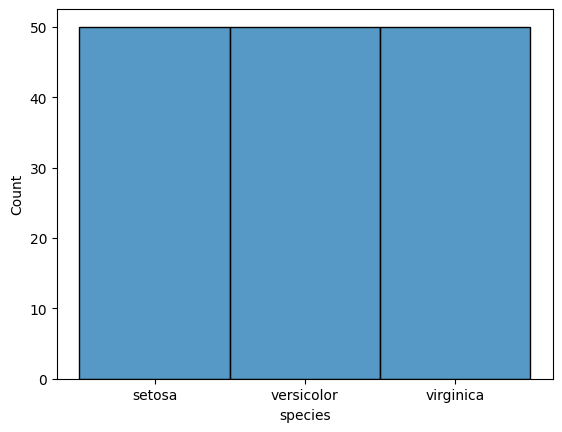

In [ ]:
sbn.histplot(df['species'])

In [ ]:
X=df.drop('species',axis=1)
y=df['species']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
lebenc=LabelEncoder()
oneHot=OneHotEncoder()

In [ ]:
y_lbl=lebenc.fit_transform(y)

In [ ]:
y_lbl

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y_lbl,test_size=.20,random_state=42,stratify=y_lbl)

In [ ]:
base_learners=[('dt',DecisionTreeClassifier(random_state=42)),
  ('svm',SVC(probability=True,kernel='rbf',random_state=42)),
  ('lr',LogisticRegression(max_iter=1000))]

In [ ]:
meta_learner=LogisticRegression(max_iter=1000)

In [ ]:
stacking_clf=StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

In [ ]:
stacking_clf.fit(X_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('svm', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [ ]:
y_pred=stacking_clf.predict(X_test)

In [ ]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest=RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [ ]:
random_forest.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rn=random_forest.predict(X_test)

In [ ]:
print(classification_report(y_pred_rn,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.82      0.86        11
           2       0.80      0.89      0.84         9

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

